Name:Amit pawar  
Prn:25070126501   
Assgnment 1:




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
df = fetch_california_housing(as_frame=True)
df.data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
df.data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [ ]:
df.data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.data
y = df.target



#train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (16512, 8)
Shape of X_test: (4128, 8)
Shape of y_train: (16512,)
Shape of y_test: (4128,)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 0.53
Mean Squared Error (MSE): 0.56
Root Mean Squared Error (RMSE): 0.75
R-squared (R2): 0.58


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"Shape of scaled X_train: {X_train_scaled.shape}")
print(f"Shape of scaled X_test: {X_test_scaled.shape}")

Features scaled successfully.
Shape of scaled X_train: (16512, 8)
Shape of scaled X_test: (4128, 8)


In [ ]:
# Scale the target variable (y) as well
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

print("Target variable scaled successfully.")

Target variable scaled successfully.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the FNN model using Input layer
model_fnn_scaled_y = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # Output layer for regression with linear activation (default)
])

# Compile the model
model_fnn_scaled_y.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

model_fnn_scaled_y.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the FNN model with scaled target
history_scaled_y = model_fnn_scaled_y.fit(
    X_train_scaled, y_train_scaled,
    epochs=100,  # Keeping the same number of epochs for comparison
    batch_size=32,
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1
)

print("FNN model trained successfully with scaled target.")

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4736 - mae: 0.4516 - val_loss: 0.3406 - val_mae: 0.4191
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2938 - mae: 0.3869 - val_loss: 0.3082 - val_mae: 0.3961
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2705 - mae: 0.3694 - val_loss: 0.3174 - val_mae: 0.3977
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2590 - mae: 0.3593 - val_loss: 0.2946 - val_mae: 0.3721
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2510 - mae: 0.3525 - val_loss: 0.3585 - val_mae: 0.3871
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2751 - mae: 0.3548 - val_loss: 0.3107 - val_mae: 0.4160
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2427 - mae: 0.3448 - val_loss: 0.2712 - val_mae: 0.3644
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2431 - mae: 0.3387 - val_loss: 0.2598 - val_mae: 0.3484
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/

In [ ]:
# Evaluate the FNN model on the scaled test set
loss_scaled_y, mae_scaled_y = model_fnn_scaled_y.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f"\nFNN Test Loss (MSE) with scaled target: {loss_scaled_y:.4f}")
print(f"FNN Test MAE with scaled target: {mae_scaled_y:.4f}")

# Make predictions on the scaled test set
y_pred_fnn_scaled = model_fnn_scaled_y.predict(X_test_scaled)

# Inverse transform the predictions and true values to original scale for meaningful R2
y_pred_fnn_original_scale = scaler_y.inverse_transform(y_pred_fnn_scaled)
y_test_original_scale = scaler_y.inverse_transform(y_test_scaled)

# Calculate additional regression metrics for FNN (on original scale)
mse_fnn_original = mean_squared_error(y_test_original_scale, y_pred_fnn_original_scale)
rmse_fnn_original = np.sqrt(mse_fnn_original)
r2_fnn_original = r2_score(y_test_original_scale, y_pred_fnn_original_scale)

print(f"FNN Test Mean Squared Error (MSE) on original scale: {mse_fnn_original:.4f}")
print(f"FNN Test Root Mean Squared Error (RMSE) on original scale: {rmse_fnn_original:.4f}")
print(f"FNN Test R-squared (R2) on original scale: {r2_fnn_original:.4f}")


FNN Test Loss (MSE) with scaled target: 0.2101
FNN Test MAE with scaled target: 0.3015
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step
FNN Test Mean Squared Error (MSE) on original scale: 0.2808
FNN Test Root Mean Squared Error (RMSE) on original scale: 0.5300
FNN Test R-squared (R2) on original scale: 0.7857


As you can see, scaling the target variable has dramatically improved the model's performance, as evidenced by the much lower MSE and a positive R-squared value, which is now comparable to the Linear Regression model.

Now, let's visualize the training history (loss and MAE curves) for this improved FNN model. These plots will help us understand the learning process and observe if the model is still learning or if there are signs of overfitting.

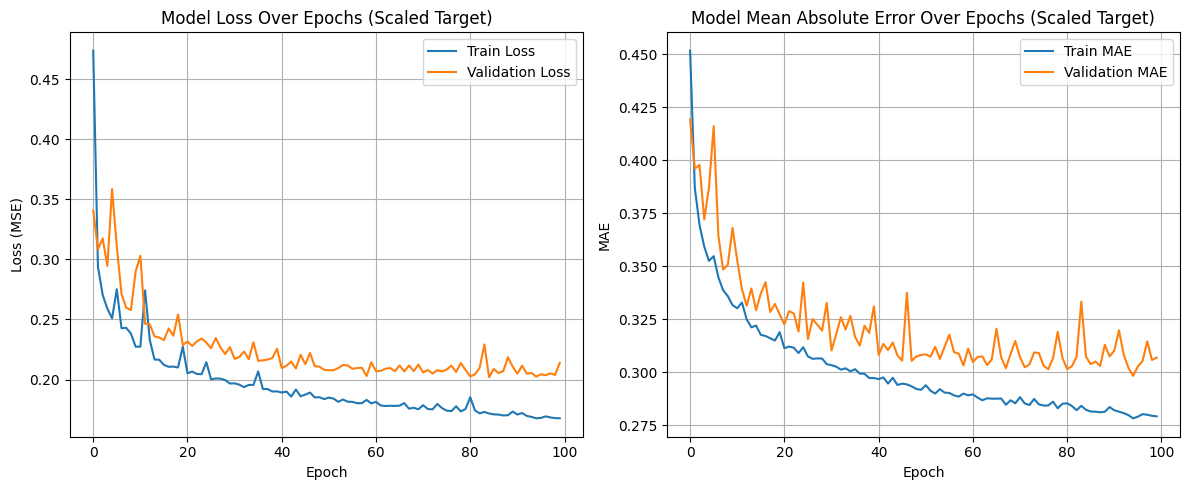

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss values for the model with scaled target
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_scaled_y.history['loss'], label='Train Loss')
plt.plot(history_scaled_y.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs (Scaled Target)')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

# Plot training & validation MAE values for the model with scaled target
plt.subplot(1, 2, 2)
plt.plot(history_scaled_y.history['mae'], label='Train MAE')
plt.plot(history_scaled_y.history['val_mae'], label='Validation MAE')
plt.title('Model Mean Absolute Error Over Epochs (Scaled Target)')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Let's visualize the model's predictions against the actual values to get a better sense of its performance. This scatter plot will show how closely our predictions align with the true housing prices.

### Implementing Lasso and Ridge Regression and re-evaluating Linear Regression with scaled target

In [ ]:
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# --- 1. Linear Regression (with scaled target) ---
model_lr_scaled_y = LinearRegression()
model_lr_scaled_y.fit(X_train_scaled, y_train_scaled)
y_pred_lr_scaled = model_lr_scaled_y.predict(X_test_scaled)
y_pred_lr_original_scale = scaler_y.inverse_transform(y_pred_lr_scaled)

mse_lr_original = mean_squared_error(y_test_original_scale, y_pred_lr_original_scale)
rmse_lr_original = np.sqrt(mse_lr_original)
r2_lr_original = r2_score(y_test_original_scale, y_pred_lr_original_scale)

print(f"\nLinear Regression (Scaled Target) - MSE: {mse_lr_original:.4f}, RMSE: {rmse_lr_original:.4f}, R2: {r2_lr_original:.4f}")




Linear Regression (Scaled Target) - MSE: 0.5559, RMSE: 0.7456, R2: 0.5758


In [ ]:
# --- 2. Lasso Regression ---
# Using a small alpha (regularization strength) for demonstration
# Alpha can be tuned using GridSearchCV or RandomizedSearchCV
lasso_model = Lasso(alpha=0.01, random_state=42)
lasso_model.fit(X_train_scaled, y_train_scaled)
y_pred_lasso_scaled = lasso_model.predict(X_test_scaled)
y_pred_lasso_original_scale = scaler_y.inverse_transform(y_pred_lasso_scaled.reshape(-1, 1))

mse_lasso_original = mean_squared_error(y_test_original_scale, y_pred_lasso_original_scale)
rmse_lasso_original = np.sqrt(mse_lasso_original)
r2_lasso_original = r2_score(y_test_original_scale, y_pred_lasso_original_scale)

print(f"Lasso Regression - MSE: {mse_lasso_original:.4f}, RMSE: {rmse_lasso_original:.4f}, R2: {r2_lasso_original:.4f}"

Lasso Regression - MSE: 0.5484, RMSE: 0.7405, R2: 0.5815


In [ ]:

# --- 3. Ridge Regression ---
# Using a small alpha (regularization strength) for demonstration
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train_scaled)
y_pred_ridge_scaled = ridge_model.predict(X_test_scaled)
y_pred_ridge_original_scale = scaler_y.inverse_transform(y_pred_ridge_scaled.reshape(-1, 1))

mse_ridge_original = mean_squared_error(y_test_original_scale, y_pred_ridge_original_scale)
rmse_ridge_original = np.sqrt(mse_ridge_original)
r2_ridge_original = r2_score(y_test_original_scale, y_pred_ridge_original_scale)

print(f"Ridge Regression - MSE: {mse_ridge_original:.4f}, RMSE: {rmse_ridge_original:.4f}, R2: {r2_ridge_original:.4f}")

Ridge Regression - MSE: 0.5559, RMSE: 0.7456, R2: 0.5758


### Comparing Model Performance

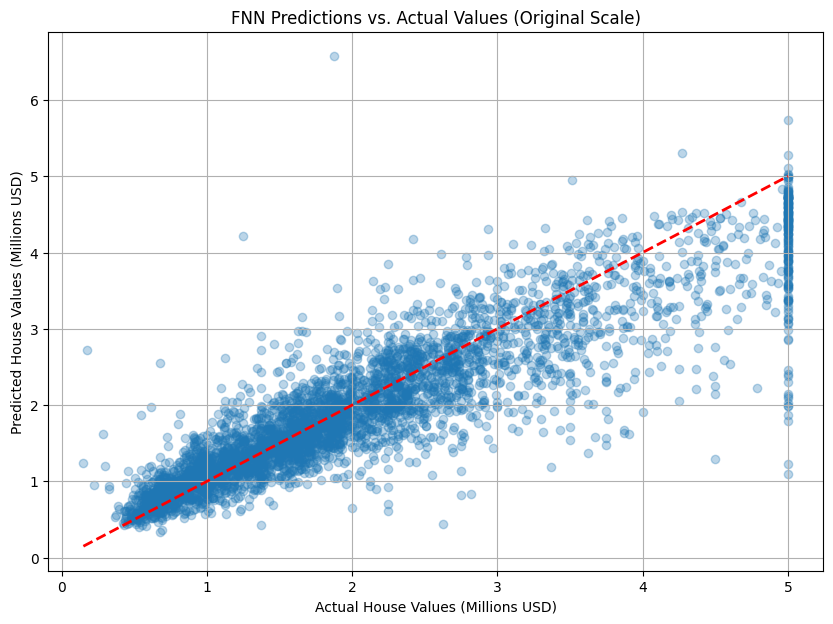

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(y_test_original_scale, y_pred_fnn_original_scale, alpha=0.3)
plt.plot([y_test_original_scale.min(), y_test_original_scale.max()],
         [y_test_original_scale.min(), y_test_original_scale.max()],
         '--r', linewidth=2) # Diagonal line for perfect predictions
plt.title('FNN Predictions vs. Actual Values (Original Scale)')
plt.xlabel('Actual House Values (Millions USD)')
plt.ylabel('Predicted House Values (Millions USD)')
plt.grid(True)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the FNN model using Input layer to avoid UserWarning
model_fnn = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)), # Recommended way to specify input shape
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # Output layer for regression with linear activation (default)
])

# Compile the model
model_fnn.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

model_fnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the FNN model
history = model_fnn.fit(
    X_train_scaled, y_train,
    epochs=100,  # You can adjust the number of epochs
    batch_size=32,
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1
)

print("FNN model trained successfully.")

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.0253 - mae: 0.6794 - val_loss: 0.4951 - val_mae: 0.4958
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4202 - mae: 0.4606 - val_loss: 0.4177 - val_mae: 0.4597
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3791 - mae: 0.4382 - val_loss: 0.4056 - val_mae: 0.4529
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3653 - mae: 0.4275 - val_loss: 0.3922 - val_mae: 0.4303
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3491 - mae: 0.4171 - val_loss: 0.3727 - val_mae: 0.4319
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3455 - mae: 0.4128 - val_loss: 0.3710 - val_mae: 0.4210
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3475 - mae: 0.4088 - val_loss: 0.3586 - val_mae: 0.4226
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3291 - mae: 0.4037 - val_loss: 0.3795 - val_mae: 0.4236
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/

In [ ]:
# Evaluate the FNN model on the test set
loss, mae = model_fnn.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nFNN Test Loss (MSE): {loss:.4f}")
print(f"FNN Test MAE: {mae:.4f}")

# Make predictions on the test set
y_pred_fnn = model_fnn.predict(X_test_scaled)

# Calculate additional regression metrics for FNN
mse_fnn = mean_squared_error(y_test, y_pred_fnn)
rmse_fnn = np.sqrt(mse_fnn)
r2_fnn = r2_score(y_test, y_pred_fnn)

print(f"FNN Test Mean Squared Error (MSE): {mse_fnn:.4f}")
print(f"FNN Test Root Mean Squared Error (RMSE): {rmse_fnn:.4f}")
print(f"FNN Test R-squared (R2): {r2_fnn:.4f}")


FNN Test Loss (MSE): 4.8912
FNN Test MAE: 1.8635
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step
FNN Test Mean Squared Error (MSE): 4.8912
FNN Test Root Mean Squared Error (RMSE): 2.2116
FNN Test R-squared (R2): -2.7326


The FNN model has been evaluated on the test set, and its performance metrics have been calculated. Now, let's visualize the training history to see how the loss and MAE evolved during training for both the training and validation sets. This will help us understand if the model is learning effectively and if there are signs of overfitting or underfitting.

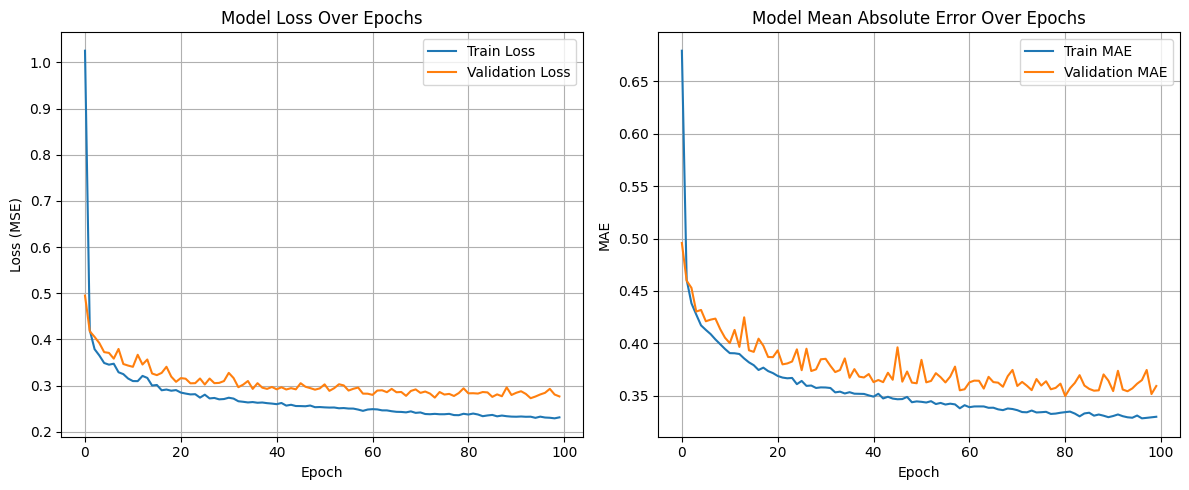

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

# Plot training & validation MAE values
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model Mean Absolute Error Over Epochs')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_734/2735669015.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=r_squared_values, palette='viridis')


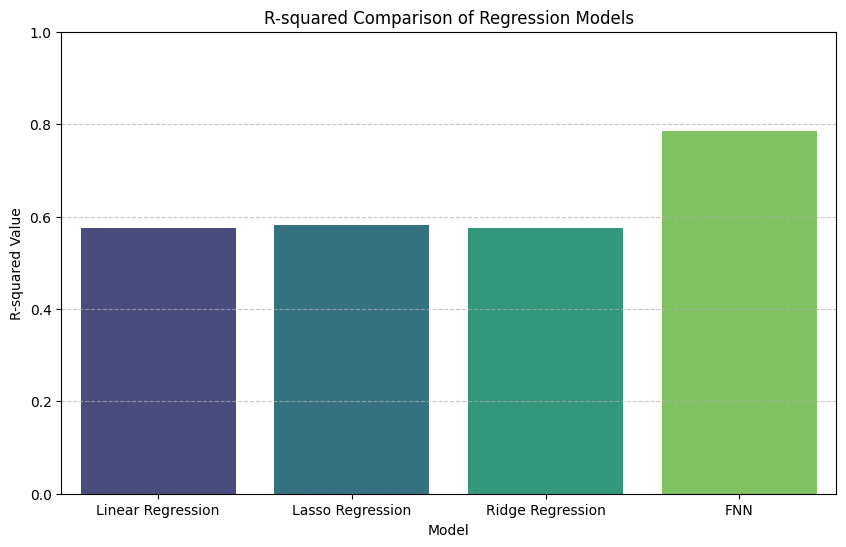


The model with the highest R-squared value is: FNN (R2: 0.7857)


In [ ]:
import matplotlib.pyplot as plt

# Store R2 scores for comparison
r2_scores = {
    'Linear Regression': r2_lr_original,
    'Lasso Regression': r2_lasso_original,
    'Ridge Regression': r2_ridge_original,
    'FNN': r2_fnn_original
}

models = list(r2_scores.keys())
r_squared_values = list(r2_scores.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=r_squared_values, palette='viridis')
plt.title('R-squared Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('R-squared Value')
plt.ylim(0, 1) # R-squared typically ranges from 0 to 1 for good models
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Determine the best model
best_model = max(r2_scores, key=r2_scores.get)
best_r2 = r2_scores[best_model]

print(f"\nThe model with the highest R-squared value is: {best_model} (R2: {best_r2:.4f})")